In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from numpy.linalg import svd, pinv

%matplotlib widget

# True Data

In [2]:
data = sio.loadmat('ES_Q1_Data.mat')
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Y', 'f'])


In [3]:
f = data['f']          # input force
Y = data['Y']          # outputs

print("Shape of f :", f.shape)
print("Shape of Y :", Y.shape)

print(f)
print(Y)

Shape of f : (1000, 1)
Shape of Y : (1000, 5)
[[ 1.67243794e+00]
 [ 7.06399481e-01]
 [-6.23516469e-01]
 [ 1.92869669e+00]
 [-9.31068412e-01]
 [ 5.88841137e-01]
 [-3.11358701e-01]
 [ 9.83066314e-01]
 [-3.45619430e-01]
 [ 1.03772253e+00]
 [-5.36353335e-01]
 [ 8.61895316e-02]
 [ 3.76145291e-01]
 [ 1.25967814e+00]
 [ 3.27153539e-02]
 [-1.02123870e+00]
 [ 1.75626380e+00]
 [ 7.03836444e-01]
 [ 6.43906318e-01]
 [ 2.30739690e-01]
 [-4.23904915e-01]
 [ 2.02514812e+00]
 [ 2.43794548e-01]
 [ 8.60134563e-01]
 [ 2.10022269e-03]
 [ 9.16466971e-01]
 [ 5.54172180e-01]
 [ 1.20247499e+00]
 [-2.27514445e-01]
 [-8.19494724e-01]
 [ 1.01814450e+00]
 [-5.28676422e-01]
 [-3.13071968e-01]
 [-6.87141846e-01]
 [-1.29778960e-01]
 [ 7.25054648e-01]
 [-1.17185077e+00]
 [-9.94402297e-01]
 [ 9.51343435e-01]
 [-5.93558493e-01]
 [-3.84253178e-01]
 [-3.60439770e-03]
 [ 3.87635469e-01]
 [ 2.67360801e-01]
 [-8.45493343e-01]
 [-6.85652087e-01]
 [-1.17765447e-01]
 [-7.74903610e-02]
 [ 5.60472942e-01]
 [-8.08001012e-01]
 [ 6

In [4]:
f = f.flatten()
Y = np.array(Y)

N = len(f)
n_outputs = Y.shape[1]

print("Number of samples =", N)
print("Number of outputs =", n_outputs)

n_markov = 100

U = np.zeros((N, n_markov))

for i in range(N):
    for j in range(n_markov):
        if i-j >= 0:
            U[i, j] = f[i-j]

print(U.shape)

Number of samples = 1000
Number of outputs = 5
(1000, 100)


In [5]:
Markov = np.zeros((n_outputs, n_markov))

U_pinv = np.linalg.pinv(U)

for r in range(n_outputs):
    
    y = Y[:, r]
    
    m = U_pinv @ y
    
    Markov[r, :] = m

print("Shape of Markov Parameters =", Markov.shape)
print(Markov)

Shape of Markov Parameters = (5, 100)
[[-8.71497684e-05  2.78418437e-02  1.01932743e-01  1.56326018e-01
  -3.60851536e-02 -3.27645380e-01 -3.00585597e-01  7.62373251e-02
   3.25792199e-01  1.33419164e-01 -2.06260677e-01 -2.31751760e-01
   4.79974519e-02  2.37949881e-01  1.42283869e-01 -3.65545956e-02
  -6.93240566e-02  2.42462824e-03  2.77068511e-02 -7.56620109e-04
   5.34323736e-04  2.01468966e-02 -1.77503394e-02 -8.92443913e-02
  -8.52421390e-02  7.91944650e-03  6.96212812e-02  2.15993857e-02
  -5.66385204e-02 -4.98985630e-02  2.85310511e-02  7.22283915e-02
   3.94443441e-02 -6.28530782e-03 -7.06863946e-03  1.52321373e-02
   1.55082591e-02 -1.63207226e-03 -6.38549175e-03 -6.50788195e-04
  -9.11580376e-03 -2.83815719e-02 -2.88368587e-02 -5.15359250e-03
   1.13366625e-02  4.43239232e-04 -1.64790972e-02 -1.05504695e-02
   1.22347218e-02  2.31463831e-02  1.35573337e-02  2.34902970e-03
   3.92802070e-03  9.79724095e-03  7.49531311e-03  3.48621179e-05
  -2.88915022e-03 -1.92675763e-03 -4.7

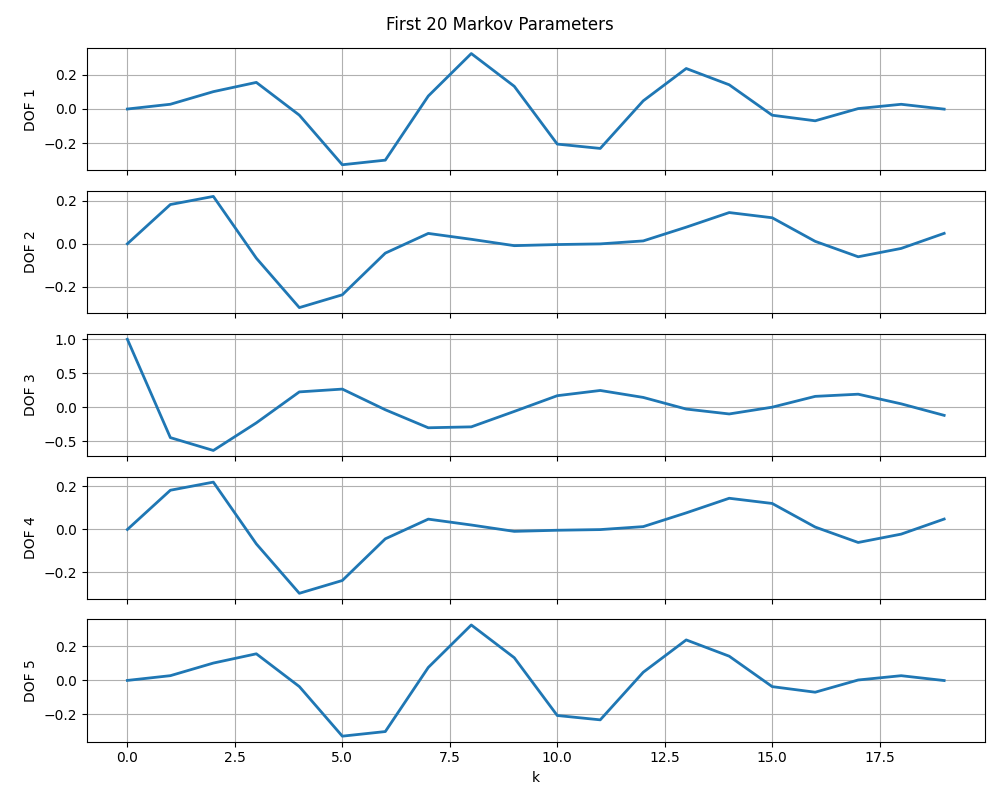

In [6]:
fig, axs = plt.subplots(5,1, figsize=(10,8), sharex=True)

for i in range(5):
    axs[i].plot(Markov[i,:20], linewidth=2)
    axs[i].set_ylabel(f'DOF {i+1}')
    axs[i].grid(True)

axs[-1].set_xlabel('k')
plt.suptitle('First 20 Markov Parameters')
plt.tight_layout()
plt.show()

In [7]:
true_data = sio.loadmat('Q1_TrueMarkovPara.mat')

print(true_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'mark_para'])


Shape of True Markov = (5, 100)
Shape of Identified Markov = (5, 100)


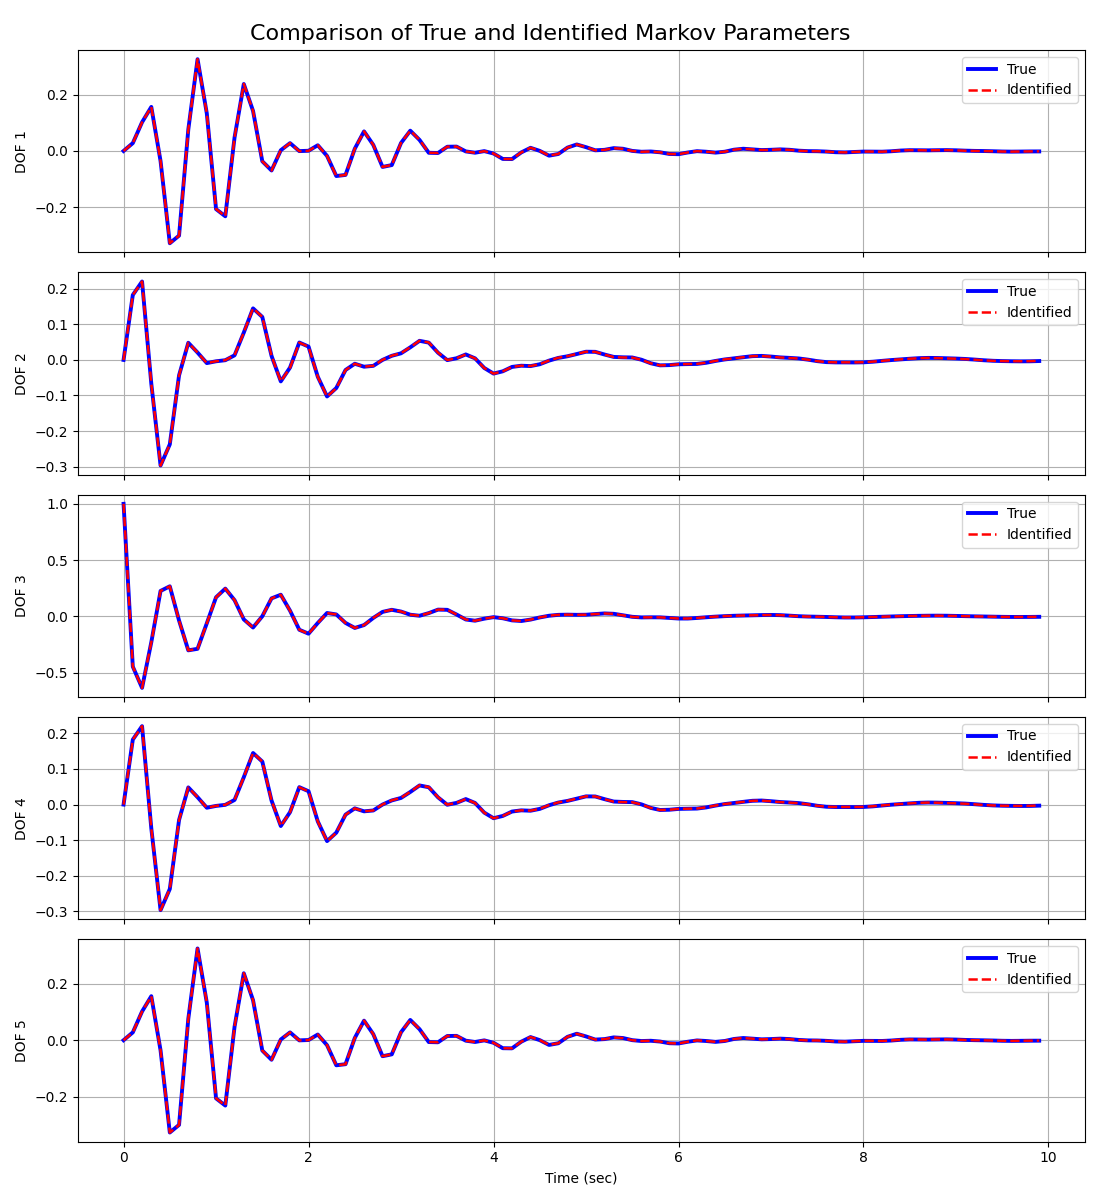

In [8]:
TrueMarkov = true_data['mark_para']

print("Shape of True Markov =", TrueMarkov.shape)
print("Shape of Identified Markov =", Markov.shape)

fs = 10
dt = 1/fs

t = np.arange(100)*dt

fig, axs = plt.subplots(5, 1, figsize=(11,12), sharex=True)

for i in range(5):

    axs[i].plot(t, TrueMarkov[i,:],
                color='blue',
                linewidth=2.8,
                label='True')

    axs[i].plot(t, Markov[i,:],
                color='red',
                linestyle='--',
                linewidth=1.8,
                label='Identified')

    axs[i].set_ylabel(f'DOF {i+1}')
    axs[i].grid(True)
    axs[i].legend(loc='upper right')

axs[-1].set_xlabel('Time (sec)')

fig.suptitle('Comparison of True and Identified Markov Parameters', fontsize=16)

plt.tight_layout()
plt.show()

In [9]:
n_inputs = 1 # only 1 force

# rows and columns
r = 40
s = 40

H1 = np.zeros((n_outputs*r, n_inputs*s))
H2 = np.zeros((n_outputs*r, n_inputs*s))

for i in range(r):
    for j in range(s):
        
        # H1 uses Y_(i+j+1)
        H1[i*n_outputs:(i+1)*n_outputs,
           j*n_inputs:(j+1)*n_inputs] = Markov[:, i+j+1].reshape(5,1)
        
        # H2 uses shifted Markov parameters
        H2[i*n_outputs:(i+1)*n_outputs,
           j*n_inputs:(j+1)*n_inputs] = Markov[:, i+j+2].reshape(5,1)

print("H1 shape =", H1.shape)
print("H2 shape =", H2.shape)

U, S, VT = svd(H1, full_matrices=False)

print("Number of singular values =", len(S))

H1 shape = (200, 40)
H2 shape = (200, 40)
Number of singular values = 40


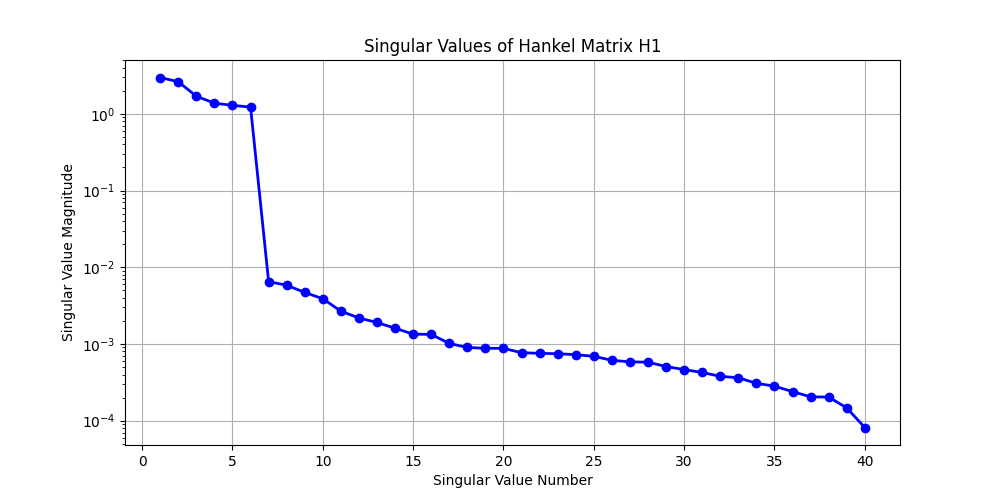

In [10]:
plt.figure(figsize=(10,5))
plt.semilogy(np.arange(1,len(S)+1), S, 'bo-', linewidth=2)
plt.xlabel('Singular Value Number')
plt.ylabel('Singular Value Magnitude')
plt.title('Singular Values of Hankel Matrix H1')
plt.grid(True)
plt.show()

We can see that a steep drop comes after n=6. Hence we truncate U, S and V after 6 entries.

In [11]:
n = 6

U1  = U[:, :n]
S1  = np.diag(S[:n])
VT1 = VT[:n, :]

S_inv_sqrt = np.diag(1/np.sqrt(S[:n]))
S_sqrt     = np.diag(np.sqrt(S[:n]))

A_d = S_inv_sqrt @ U1.T @ H2 @ VT1.T @ S_inv_sqrt

C_d = U1[:n_outputs, :] @ S_sqrt

B_d = S_sqrt @ VT1[:, :n_inputs]

D_d = Markov[:,0].reshape(n_outputs,1)

In [12]:
print("A_d shape =", A_d.shape)
print("B_d shape =", B_d.shape)
print("C_d shape =", C_d.shape)
print("D_d shape =", D_d.shape)

A_d shape = (6, 6)
B_d shape = (6, 1)
C_d shape = (5, 6)
D_d shape = (5, 1)


In [13]:
eigvals, eigvecs = np.linalg.eig(A_d)

s = np.log(eigvals) / dt

idx = np.where(np.imag(s) > 0)[0]

s_sel   = s[idx]
phi_sel = eigvecs[:, idx]

n_modes = len(idx)

print("Identified modes =", n_modes)

freq_Hz = []
zeta = []
ModeShapes = np.zeros((5, n_modes))


for j in range(n_modes):
    
    sj   = s_sel[j]
    phij = phi_sel[:, j]
    
    wn = np.abs(sj)
    fj = wn / (2*np.pi)
    
    zj = -np.real(sj) / wn
    
    psi = C_d @ phij
    
    k = np.argmax(np.abs(psi))
    theta = -np.angle(psi[k])
    
    v = np.real(psi * np.exp(1j*theta))
    
    v = v / np.max(np.abs(v))
    
    freq_Hz.append(fj)
    zeta.append(zj)
    ModeShapes[:,j] = v

Identified modes = 3


In [14]:
freq_Hz = np.array(freq_Hz)
zeta    = np.array(zeta)

for j in range(n_modes):
    print(f"Mode {j+1}")
    print("Frequency (Hz) =", freq_Hz[j])
    print("Damping Ratio =", zeta[j])
    print("Mode Shape =", ModeShapes[:,j])
    print()

Mode 1
Frequency (Hz) = 2.2289289801594467
Damping Ratio = 0.04998553106804653
Mode Shape = [ 1.         -0.45147348  0.31117806 -0.45147348  1.        ]

Mode 2
Frequency (Hz) = 1.6861497207296117
Damping Ratio = 0.07999792589606575
Mode Shape = [-0.67507929 -0.40295873  1.         -0.40295873 -0.67507929]

Mode 3
Frequency (Hz) = 0.5431690806239412
Damping Ratio = 0.09976953179821971
Mode Shape = [0.46085402 0.8546357  1.         0.8546357  0.46085402]



In [15]:
true_modal = sio.loadmat('Q1_TrueModalPara.mat')

print(true_modal.keys())

print(true_modal)

dict_keys(['__header__', '__version__', '__globals__', 'damp', 'MS', 'freq'])
{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sun Apr 09 17:52:52 2017', '__version__': '1.0', '__globals__': [], 'damp': array([[0.1 , 0.1 , 0.08, 0.08, 0.05]]), 'MS': array([[ 2.81845199e-01, -4.59700843e-01, -5.05936655e-01,
        -8.88073834e-01,  8.15224745e-01],
       [ 5.22720726e-01, -6.27963030e-01, -3.02028137e-01,
         3.25057584e-01, -3.68160356e-01],
       [ 6.11628457e-01, -1.11036572e-17,  7.49390492e-01,
         0.00000000e+00,  2.53622791e-01],
       [ 5.22720726e-01,  6.27963030e-01, -3.02028137e-01,
        -3.25057584e-01, -3.68160356e-01],
       [ 2.81845199e-01,  4.59700843e-01, -5.05936655e-01,
         8.88073834e-01,  8.15224745e-01]]), 'freq': array([[0.54273902, 1.13344657, 1.68616034, 2.18965063, 2.22889936]])}


In [16]:
f_true = true_modal['freq'].flatten()
zeta_true = true_modal['damp'].flatten()
Phi_true = true_modal['MS']

print("True frequencies shape =", f_true.shape)
print("True damping shape =", zeta_true.shape)
print("True mode shapes shape =", Phi_true.shape)

idx_sort = np.argsort(freq_Hz)

freq_id = freq_Hz[idx_sort]
zeta_id = zeta[idx_sort]
Phi_id  = ModeShapes[:, idx_sort]

print("Identified frequencies =", freq_id)
print("Identified damping =", zeta_id)

True frequencies shape = (5,)
True damping shape = (5,)
True mode shapes shape = (5, 5)
Identified frequencies = [0.54316908 1.68614972 2.22892898]
Identified damping = [0.09976953 0.07999793 0.04998553]


In [17]:
# MAC Function

def MAC(u, v):
    u = np.array(u).reshape(-1,1)
    v = np.array(v).reshape(-1,1)
    
    num = np.abs(u.T @ v)**2
    den = (u.T @ u) * (v.T @ v)
    
    return float(num / den)

In [18]:
results = []

used = []

for i in range(len(freq_id)):
    
    diff = np.abs(f_true - freq_id[i])
    
    for j in used:
        diff[j] = 1e9
    
    jbest = np.argmin(diff)
    used.append(jbest)
    
    ft = f_true[jbest]
    zt = zeta_true[jbest]
    phit = Phi_true[:, jbest]
    
    fi = freq_id[i]
    zi = zeta_id[i]
    phii = Phi_id[:, i]
    
    if np.dot(phii, phit) < 0:
        phii = -phii
    
    err_f = (fi-ft)/ft * 100
    err_z = (zi-zt)/zt * 100
    
    mac_val = MAC(phii, phit)
    
    results.append([
        i+1,           # identified mode no.
        jbest+1,       # matched true mode no.
        fi, ft,
        zi, zt,
        err_f,
        err_z,
        mac_val
    ])

C:\Users\Kushagra\AppData\Local\Temp\ipykernel_35084\37750654.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(num / den)


In [19]:
columns = [
    'Identified Mode',
    'True Mode',
    'Identified f (Hz)',
    'True f (Hz)',
    'Identified zeta',
    'True zeta',
    '% Error f',
    '% Error zeta',
    'MAC'
]

df = pd.DataFrame(results, columns=columns)

df

,Identified Mode,True Mode,Identified f (Hz),True f (Hz),Identified zeta,True zeta,% Error f,% Error zeta,MAC
0,1,1,0.543169,0.542739,0.099770,0.10,0.079238,-0.230468,1.0
1,2,3,1.686150,1.686160,0.079998,0.08,-0.000630,-0.002593,1.0
2,3,5,2.228929,2.228899,0.049986,0.05,0.001329,-0.028938,1.0


Only one external force was applied.

If force is applied at one DOF, modes having small modal amplitude at that DOF receive little energy.

So those modes barely appear in output data.

This means their Markov contribution is tiny.